In [25]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis/')

from libs import crudo

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from scipy.optimize import curve_fit
# Styling Plot
crudo.pt.ccortesp_plot_style()
# PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# -------------------
# 1. FILE INFORMATION
# -------------------
# Filename tag
VERSION_TAG = ['fiducial_p2_icaros.h5', 'fiducial_p2_zemrude.h5']
# Directory
INPUT_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/'

FILENAMES = [os.path.join(INPUT_DIR, filename) for filename in VERSION_TAG]



# -----------------
# 3. PLOT SETTINGS
# -----------------
RAS_ON_CORRECTED_TIME  = 3485614.533823055      # in [s]

In [5]:
DATAFRAMES = {
                'icaros'  : {'duration': RAS_ON_CORRECTED_TIME, 'fiducial': pd.DataFrame()},
                'zemrude' : {'duration': RAS_ON_CORRECTED_TIME, 'fiducial': pd.DataFrame()}
}



In [6]:
for i, city in enumerate(DATAFRAMES.keys()):
    # Load DataFrame
    DATAFRAMES[city]['fiducial'] = pd.read_hdf(FILENAMES[i], key='Events')

In [7]:
DATAFRAMES

{'icaros': {'duration': 3485614.533823055,
  'fiducial':            event  npeak      E_peak_pe  n_hits_peak      X_bary      Y_bary  \
  32         26181     30  130226.652027          410   38.554585  247.627791   
  40         30920     28  312293.863779         1099  108.943233 -121.984925   
  192       142283     20  153637.862374          665 -271.089302  -59.023589   
  267       199193     26  231479.343931         1095   44.219886  194.564626   
  281       212990     24  173860.064759          586   62.259331  301.627033   
  ...          ...    ...            ...          ...         ...         ...   
  1005106  1541022     24  112500.301624          405 -300.334130 -170.797251   
  1005132  1568980     19  219427.325421          743  235.460241 -128.646102   
  1005169  1609104     32  113996.393012          315  204.192083 -179.816728   
  1005223  1662052     33  117331.260518          440 -185.313855   50.970500   
  1005346  1781318     22  128765.101007          382 

# Energy Analysis


ICAROS:
  Counts = 12568, corr. time = 3485614.53 s | Rate = 3.6057 mHz
  Center of the DEP bin: 1.6500 MeV | 
  Fit results:
    μ = (1.6532 ± 0.0014) MeV
    σ = (0.0096 ± 0.0016) MeV
    R(%) = (1.36 ± 0.22)%

ZEMRUDE:
  Counts = 7797, corr. time = 3485614.53 s | Rate = 2.2369 mHz
  Center of the DEP bin: 1.6100 MeV | 
  Fit results:
    μ = (1.5994 ± 0.0019) MeV
    σ = (0.0090 ± 0.0018) MeV
    R(%) = (1.33 ± 0.26)%


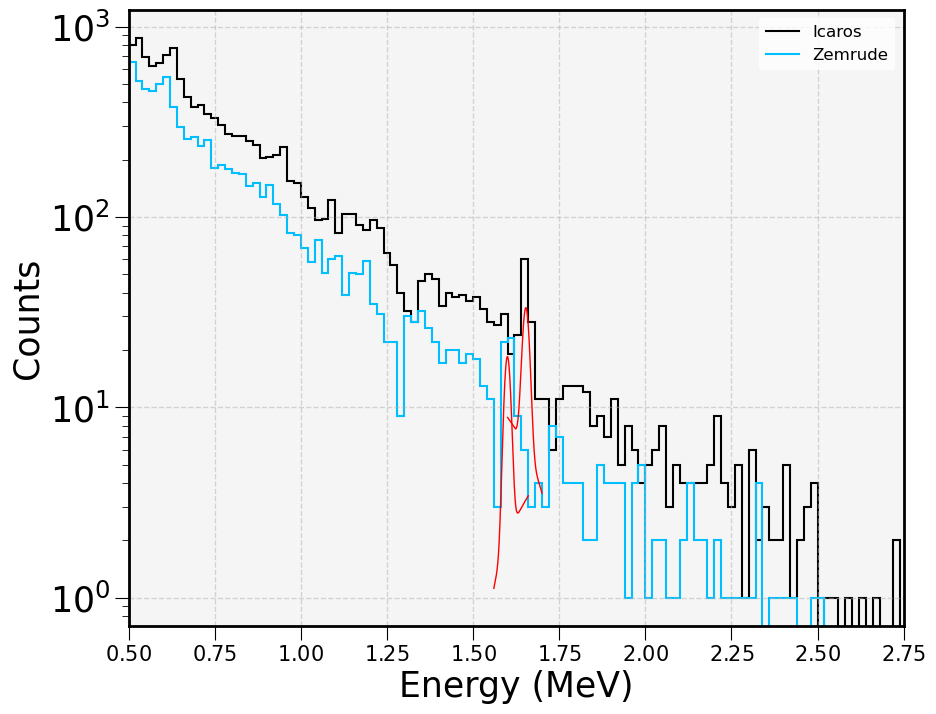

In [62]:
# Global
n_bins = 125
DEP_VALUE = 1.593       # MeV

# Dataframes
FIDU_ICAROS_DF  = DATAFRAMES['icaros']['fiducial']
FIDU_ZEMRUDE_DF = DATAFRAMES['zemrude']['fiducial']

# ----- Define the Binning ----- #
_, plot_edges = np.histogram(FIDU_ICAROS_DF['E_evt_mev'].unique(), bins=n_bins, range=(FIDU_ICAROS_DF['E_evt_mev'].min(), 3))

for i, dataframe in enumerate([FIDU_ICAROS_DF, FIDU_ZEMRUDE_DF]):

    if i == 0: label = 'Icaros'
    else:      label = 'Zemrude'

    # Variable
    # E_evt = dataframe['E_evt_mev'].unique() - shift_value
    E_evt = dataframe['E_evt_mev'].unique()

    # Histogram
    counts, bin_edges = np.histogram(E_evt, bins=plot_edges)
    rate = counts / (RAS_ON_CORRECTED_TIME)     # in [Hz]
    print(f"\n{label.upper()}:\n  Counts = {counts.sum()}, corr. time = {RAS_ON_CORRECTED_TIME:.2f} s | Rate = {rate.sum()*1e3:.4f} mHz")

    # ----- DEP Histogram Peak ----- #
    mask = (bin_edges[:-1] >= 1.55) & (bin_edges[:-1] <= 1.75)  
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    # Find the bin with the highest count in the specified range
    peak_bin_index  = np.argmax(counts[mask])
    peak_bin_center = bin_centers[mask][peak_bin_index]
    # shift_value = peak_bin_center - DEP_VALUE
    print(f"  Center of the DEP bin: {peak_bin_center:.4f} MeV | ")
    # print(f"  Shift value: {shift_value:.4f} MeV")
    # Plot line
    # plt.axvline(peak_bin_center, c=crudo.pt.hist_colors[i % len(crudo.pt.hist_colors)], ls='--', lw=1.0)

    # ----- Fitting ----- #
    calib_range = (peak_bin_center - 0.05, peak_bin_center + 0.05)
    popt, pcov, hist_data = fit_peak_crystal_ball(E_evt, peak_bin_center, calib_range)
    # Results
    mu, sigma = popt[1], abs(popt[2])
    mu_err, sigma_err = np.sqrt(pcov[1, 1]), np.sqrt(pcov[2, 2])
    res_cv  = 2.355 * sigma / mu * 100
    res_err = res_cv * np.sqrt((sigma_err/sigma)**2 + (mu_err/mu)**2) if sigma > 0 else np.nan
    print(f"  Fit results:\n    μ = ({mu:.4f} ± {mu_err:.4f}) MeV\n    σ = ({sigma:.4f} ± {sigma_err:.4f}) MeV\n    R(%) = ({res_cv:.2f} ± {res_err:.2f})%")


    # ----- Plotting ----- #
    # Data
    plt.stairs(counts, bin_edges, label=f'{label}', 
               fill=False, lw=1.5, ec=crudo.pt.hist_colors[3*i % len(crudo.pt.hist_colors)])

    # Fit
    fit_x = np.linspace(calib_range[0], calib_range[1], 300)
    plt.plot(fit_x, crystal_ball_with_linear_bg(fit_x, *popt), 'r-', lw=1.0)
    # Plot the data points used for the fit
    # plt.scatter(hist_data[0], hist_data[1], color='blue', marker='o', s=50, label=f'Fit Data Points ({label})')

    # # Highlight the fitted mean
    # # plt.scatter(mu, crystal_ball_with_linear_bg(mu, *popt), color='red', marker='x', s=100, label=f'μ ({label})')


# Lines
# plt.axvline(x=DEP_VALUE, c='green', ls='--', lw=1.0, label='DEP Peak (Nominal)')

# ----- Styling ----- #
plt.xlabel('Energy (MeV)')
plt.xlim(1.5, 1.8)
plt.xticks(np.arange(0.5, 3.0, 0.25))
plt.xticks(fontsize=15)
plt.ylabel('Counts')
# plt.ylim(1e-7, 1e-2)
plt.yscale('log')
plt.legend(loc='upper right', fontsize=12)

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
# plt.savefig('/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/images/Energy_Bckg_Inclusive_Fiducial.pdf')
plt.show()

In [45]:
def crystal_ball_with_linear_bg(x, amplitude, mu, sigma, alpha, n, slope, intercept):
    '''
    Crystal Ball function with a linear background.
    '''
    # Failsafes for stability
    sigma = abs(sigma) if sigma != 0 else 1e-9
    alpha = abs(alpha) if alpha != 0 else 1e-9
    n = abs(n) if n != 0 else 1e-9

    t = (x - mu) / sigma
    
    # Gaussian part
    # gauss = amplitude * np.exp(-0.5 * t**2)
    
    # Power-law tail part
    if n / alpha > 1e6: # Heuristic to prevent overflow
        A = 1e99
    else:
        A = (n / alpha)**n * np.exp(-0.5 * alpha**2)
    B = n / alpha - alpha
    # A = (n / abs(alpha))**n * np.exp(-0.5 * alpha**2)
    # B = n / abs(alpha) - abs(alpha)
    # tail = amplitude * A * (B - t)**(-n)

    tail_base = B - t

    gauss = np.exp(-0.5 * t**2)

    # Power-law tail part (only where the base is positive)
    tail = A * np.power(tail_base, -n, where=tail_base > 0, out=np.full_like(tail_base, 0))

    # Combine using masks based on the `t` variable
    cb_shape = np.where(t > -alpha, gauss, tail)
    
    # Combine using masks
    # cb_shape = np.where(t > -alpha, gauss, tail)
    
    return amplitude * cb_shape + (slope * x + intercept)
    # return cb_shape + (slope * x + intercept)

def fit_peak_crystal_ball(data, mu_guess, fit_range, bins='auto'):
    '''
    Fits a Crystal Ball + linear background to a peak.
    '''
    y, bin_edges = np.histogram(data, bins=bins, range=fit_range)
    x = (bin_edges[:-1] + bin_edges[1:]) / 2

    if np.sum(y) < 50: 
        return None, None, (x, y)
    
    # Smart guesses
    slope_guess     = (np.mean(y[-5:]) - np.mean(y[:5])) / (x[-1] - x[0])
    intercept_guess = np.mean(y[:5]) - slope_guess * x[0]
    amplitude_guess = y.max() - (slope_guess * mu_guess + intercept_guess)
    sigma_guess = (fit_range[1] - fit_range[0]) / 10
    
    # Crystal ball specific guesses: alpha controls where tail starts, n controls shape
    alpha_guess = 1.0 
    n_guess = 2.0
    
    p0 = [amplitude_guess, mu_guess, sigma_guess, alpha_guess, n_guess, slope_guess, intercept_guess]

    # --- DEFINE BOUNDS ---
    # This is the crucial step to stabilize the fit.
    # It constrains the values the fitter is allowed to try.
    # Format: ([lower bounds], [upper bounds])
    bounds = (
        [0,       fit_range[0], 0,     0,     0,     -np.inf, -np.inf], # Lower bounds
        [np.inf,  fit_range[1], np.inf, 10,    10,    np.inf,  np.inf]  # Upper bounds
    )
    # Explanation of bounds:
    # amplitude: must be positive
    # mu: must be within the fit range
    # sigma, alpha, n: must be positive. We also set a reasonable upper limit for alpha/n.
    # slope, intercept: can be anything.

    try:
        popt, pcov = curve_fit(crystal_ball_with_linear_bg, x, y, p0=p0, sigma=np.sqrt(np.maximum(y, 1)), bounds=bounds, maxfev=10000)
        return popt, pcov, (x, y)
    except (RuntimeError, ValueError) as e:
        print(f"   Fit failed for peak near {mu_guess:.1f}. Reason: {e}")
        return None, None, (x, y)

In [22]:
KNOWN_PEAKS_PES = {
                        # "511 keV":   {'real_MeV': 0.511,  'guess': 98e3,  'range': (88e3, 108e3)},
                        # "583 keV":   {'real_MeV': 0.583,  'guess': 113e3, 'range': (103e3, 123e3)},
                        # "727 keV":   {'real_MeV': 0.727,  'guess': 141e3, 'range': (131e3, 151e3)},
                        # "860 keV":   {'real_MeV': 0.860,  'guess': 167e3, 'range': (157e3, 177e3)},
                        "DE Peak":   {'real_MeV': 1.592,  'guess': 313e3, 'range': (293e3, 333e3)},
                        # "Tl Peak":   {'real_MeV': 2.615,  'guess': 515e3, 'range': (495e3, 535e3)}
}

In [ ]:
def calibrate_pes_to_MeV_and_get_resolution(
                                                event_energies_df: pd.DataFrame,    # Expects energy in MeV
                                                known_peaks_pes: dict               # Dictionary with guesses/ranges in PE
):
    """
    A full pipeline that:
    1. Fits peaks in the uncalibrated 'pes' spectrum.
    2. Determines the linear pes -> MeV calibration.
    3. Applies the calibration.
    4. Re-fits the peaks in the calibrated MeV spectrum to find the resolution.
    """
    print(f"\n{'='*20} Running PE → MeV Calibration {'='*20}")
    energies_MeV = event_energies_df['E_evt_mev']
    
    # -----  Final Fits in MeV ----- #
    print("\nComputing final energy resolution...")
    fig_final, axes_final = plt.subplots(int(np.ceil(len(known_peaks_pes)/2)), 2, figsize=(16, 5*np.ceil(len(known_peaks_pes)/2)))
    axes_final = axes_final.flatten()
    fig_final.suptitle(f'Final Resolution Fits (in MeV)', fontsize=25, y=0.94)

    final_resolution_results = []
    for i, (peak_name, props) in enumerate(known_peaks_pes.items()):
        ax = axes_final[i]
        # --- Fitting
        real_E = props['real_MeV']
        
    
    return pd.DataFrame(final_resolution_results)


==================== Running PE → MeV Calibration ====================

Computing final energy resolution...
   Fit failed for peak near 1.6. Reason: Optimal parameters not found: Number of calls to function has reached maxfev = 1600.


/tmp/ccortesp/ipykernel_1005669/3877755784.py:18: RuntimeWarning: invalid value encountered in power
  tail = amplitude * A * (B - t)**(-n)


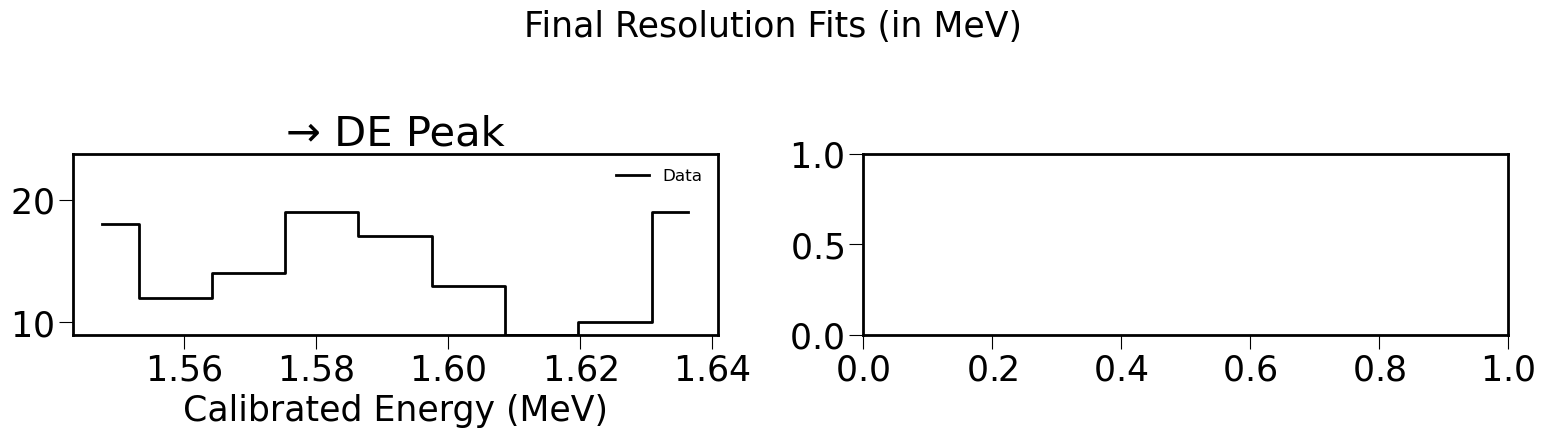


----- Final Summary -----
Empty DataFrame
Columns: []
Index: []


In [30]:
resolution_table = calibrate_pes_to_MeV_and_get_resolution(
                                                                                    event_energies_df=FIDU_ICAROS_DF,
                                                                                    known_peaks_pes=KNOWN_PEAKS_PES
                                                                             )

print("\n----- Final Summary -----")

print(resolution_table)